# DX 704 Week 2 Project

This week's project will analyze fresh strawberry price data for a hypothetical "buy low, freeze, and sell high" business.
Strawberries show strong seasonality in their prices compared to other fruits.

![](https://ers.usda.gov/sites/default/files/_laserfiche/Charts/61401/oct14_finding_plattner_fig01.png)

Image source: https://www.ers.usda.gov/amber-waves/2014/october/seasonal-fresh-fruit-price-patterns-differ-across-commodities-the-case-of-strawberries-and-apples

You are considering a business where you buy strawberries when the prices are very low, carefully freeze them, even more carefully defrost them, and then sell them when the prices are high.
You will forecast strawberry price time series and then use them to tactically pick times to buy, freeze, and sell the strawberries.

The full project description, a template notebook, and raw data are available on GitHub at the following link.

https://github.com/bu-cds-dx704/dx704-project-02


### Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Backtest Strawberry Prices

Read the provided "strawberry-prices.tsv" with data from 2020 through 2025.
This data is based on data from the U.S. Bureau of Statistics, but transformed so the ground truth is not online.
https://fred.stlouisfed.org/series/APU0000711415

Use the data for 2020 through 2024 to predict monthly prices in 2025.
Spend some time to make sure you are happy with your methodology and prediction accuracy, since you will reuse the methodology to forecast 2026 next.
Save the 2025 backtest predictions as "strawberry-backtest.tsv" with columns month and price.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [76]:
# Read CSV

strawberry_data = pd.read_csv("strawberry-prices.tsv", sep="\t")

# make date column actual dates and then make it the index
strawberry_data["month"] = pd.to_datetime(strawberry_data["month"], format="%Y-%m-%d")
strawberry_data = strawberry_data.sort_values("month")

strawberry_data.head()

,month,price
0,2020-01-01,4.049
1,2020-02-01,3.625
2,2020-03-01,3.377
3,2020-05-01,3.126
4,2020-06-01,2.926


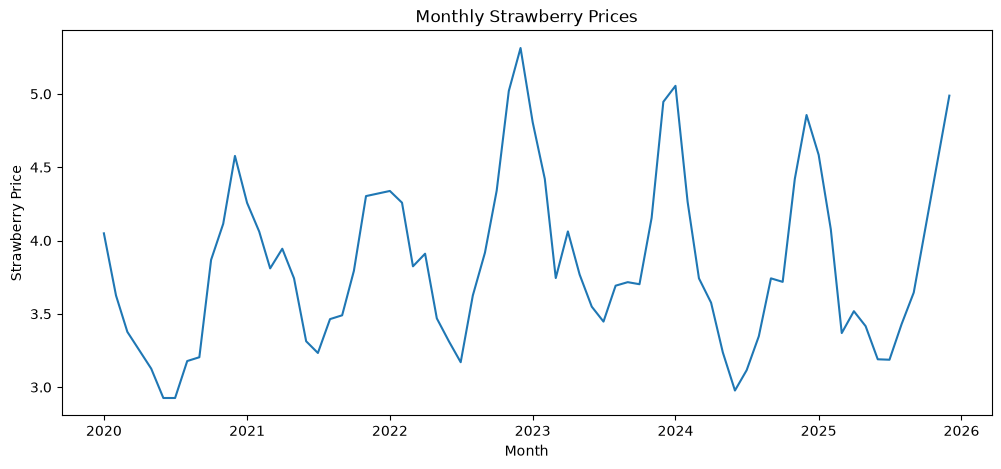

In [77]:
# Plot the series
plt.figure(figsize=(12,5))
plt.plot(
    strawberry_data["month"],
    strawberry_data["price"]
)

plt.xlabel("Month")
plt.ylabel("Strawberry Price")
plt.title("Monthly Strawberry Prices")
plt.show()

In [78]:
# Seperate the historical period from 2025 
train = strawberry_data[
    strawberry_data["month"].dt.year <= 2024
].copy()

actual_2025 = strawberry_data[
    strawberry_data["month"].dt.year == 2025
].copy()

print(train.shape)
print(actual_2025.shape)

(58, 2)
(10, 2)


In [79]:
# Backtest methodology before predicting 2025 
backtest_train = strawberry_data[
    strawberry_data["month"].dt.year <=2023
].copy()

backtest_actual = strawberry_data[
    strawberry_data["month"].dt.year == 2024
].copy()

In [80]:
# Baseline: Seasonal Naive 
seasonal_naive_predictions = (
    strawberry_data[
        strawberry_data["month"].dt.year == 2023
    ]["price"]
    .to_numpy()
)

In [81]:
# Evaluate 
mae_naive = mean_absolute_error(
    backtest_actual["price"],
    seasonal_naive_predictions
)

rmse_naive = np.sqrt(
    mean_squared_error(
        backtest_actual["price"],
        seasonal_naive_predictions
    )
)

print("Seasonal Naive MAE:", mae_naive)
print("Seasonal Naive RMSE:", rmse_naive)

Seasonal Naive MAE: 0.2557499999999999
Seasonal Naive RMSE: 0.321397858321012


In [82]:
# Try an Autoregressive Model
# Start with an autoregression containing both short-term lag and the same month from the previous year
y_train = backtest_train["price"].to_numpy()

In [83]:
ar_model = AutoReg(
    y_train,
    lags=[1,12], # 1 = previous month, 12 = same month one year earlier 
    trend="ct" # c = intercept, t = time trend
)

ar_fit = ar_model.fit()

In [84]:
# Predict the 12 months of 2024
ar_predictions_2024 = ar_fit.predict(
    start=len(y_train),
    end=len(y_train) + 11,
    dynamic=False
)

In [85]:
# Evaluate 
mae_ar = mean_absolute_error(
    backtest_actual["price"],
    ar_predictions_2024
)

rmse_ar = np.sqrt(
    mean_squared_error(
        backtest_actual["price"],
        ar_predictions_2024
    )
)

print("AR MAE:", mae_ar)
print("AR RMSE:", rmse_ar)

AR MAE: 0.5676759330638786
AR RMSE: 0.6444074353739568


In [86]:
# Compare the models visually
comparison = pd.DataFrame({
    "month": backtest_actual["month"].to_numpy(),
    "actual": backtest_actual["price"].to_numpy(),
    "seasonal_naive": seasonal_naive_predictions,
    "autoregression": np.asarray(ar_predictions_2024)
})

comparison

,month,actual,seasonal_naive,autoregression
0,2024-01-01,5.055,4.807,4.912075
1,2024-02-01,4.264,4.420,4.763926
2,2024-03-01,3.742,3.744,4.451158
3,2024-04-01,3.576,4.062,4.372656
4,2024-05-01,3.237,3.768,4.229054
5,2024-06-01,2.977,3.549,4.071763
6,2024-07-01,3.116,3.447,3.945432
7,2024-08-01,3.347,3.692,3.953533
8,2024-09-01,3.742,3.716,3.967799
9,2024-10-01,3.718,3.702,3.973032


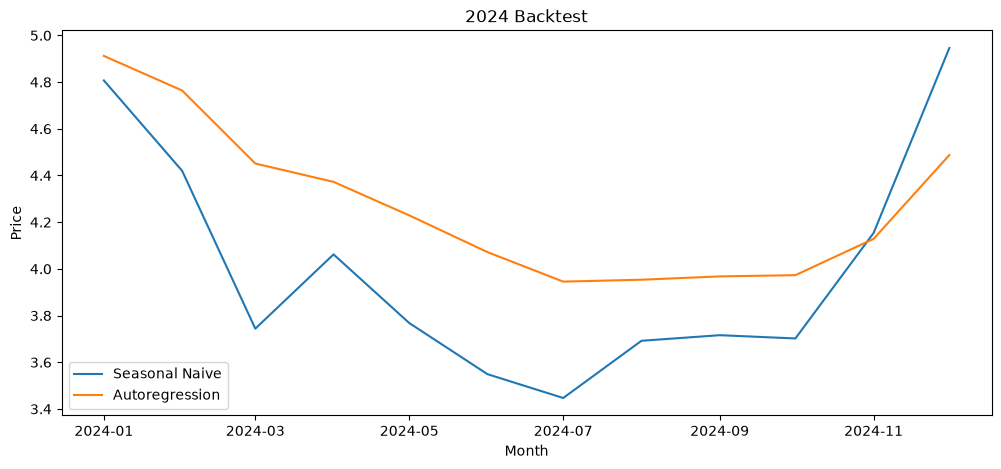

In [87]:
plt.figure(figsize=(12,5))

plt.plot(
    comparison["month"],
    comparison["seasonal_naive"],
    label="Seasonal Naive"
)

plt.plot(
    comparison["month"],
    comparison["autoregression"],
    label="Autoregression"
)

plt.xlabel("Month")
plt.ylabel("Price")
plt.title("2024 Backtest")
plt.legend()
plt.show()

In [88]:
# Create a simple accuracy table 
model_results = pd.DataFrame({
    "model": [
        "Seasonal Naive",
        "Autoregression"
    ],
    "MAE" : [
        mae_naive,
        mae_ar
    ],
    "RMSE": [
        rmse_naive,
        rmse_ar
    ]
})

model_results

,model,MAE,RMSE
0,Seasonal Naive,0.255750,0.321398
1,Autoregression,0.567676,0.644407


In [89]:
# Use Seasonal Naive as forecasting methodology due to lower MAE and RMSE

# Use each 2024 month's price as the prediction for the corresponding month in 2025

predictions_2025 = strawberry_data[
    strawberry_data["month"].dt.year == 2024
]["price"].to_numpy()

predictions_2025

array([5.055, 4.264, 3.742, 3.576, 3.237, 2.977, 3.116, 3.347, 3.742,
       3.718, 4.42 , 4.856])

In [90]:
# Create required Output
months_2025 = pd.date_range(
    start="2025-01-01",
    periods=12,
    freq="MS"
)

strawberry_backtest = pd.DataFrame({
    "month": months_2025,
    "price": predictions_2025
})

strawberry_backtest

,month,price
0,2025-01-01,5.055
1,2025-02-01,4.264
2,2025-03-01,3.742
3,2025-04-01,3.576
4,2025-05-01,3.237
5,2025-06-01,2.977
6,2025-07-01,3.116
7,2025-08-01,3.347
8,2025-09-01,3.742
9,2025-10-01,3.718


In [91]:
strawberry_backtest.to_csv(
    "strawberry-backtest.tsv",
    sep="\t",
    index=False
)

Please use the same format for the month column as in the training data, i.e. YYYY-MM-01.
The autograder may not be able to parse other formats.

Submit "strawberry-backtest.tsv" in Gradescope.

## Part 2: Backtest Errors

What are the mean and standard deviation of the residuals between your backtest predictions and the ground truth?

Write the mean and standard deviation to a file "backtest-accuracy.tsv" with two columns, mean and std.

In [92]:
# Use the actual 2025 prices to calculate residuals 
# residuals = actual price - predicted price 

# Get the actual 2025 prices
actual_2025 = strawberry_data[
    strawberry_data["month"].dt.year == 2025
][["month", "price"]].copy()

actual_2025 = actual_2025.rename(
    columns={"price": "actual_price"}
)

# Predicted 2025 prices from Part 1
# Use a merge due to 2025 actuals containing 10 values while predictions contain 12
predicted_2025 = strawberry_backtest.copy()

predicted_2025["month"] = pd.to_datetime(
    predicted_2025["month"]
)

predicted_2025 = predicted_2025.rename(
    columns={"price": "predicted_price"}
)

# Merge
backtest_comparison = actual_2025.merge(
    predicted_2025,
    on="month",
    how="inner"
)

In [93]:
# Calculate the Residuals
backtest_comparison["residual"] = (
    backtest_comparison["actual_price"]
    - backtest_comparison["predicted_price"]
)

backtest_comparison

,month,actual_price,predicted_price,residual
0,2025-01-01,4.584,5.055,-0.471
1,2025-02-01,4.077,4.264,-0.187
2,2025-03-01,3.369,3.742,-0.373
3,2025-04-01,3.518,3.576,-0.058
4,2025-05-01,3.416,3.237,0.179
5,2025-06-01,3.190,2.977,0.213
6,2025-07-01,3.187,3.116,0.071
7,2025-08-01,3.430,3.347,0.083
8,2025-09-01,3.645,3.742,-0.097
9,2025-12-01,4.988,4.856,0.132


In [94]:
# Get the residual mean and stdev
residual_mean = backtest_comparison["residual"].mean()
residual_std = backtest_comparison["residual"].std(ddof=1)

print("Mean:", residual_mean)
print("Standard deviation:", residual_std)

Mean: -0.0508
Standard deviation: 0.2332546534012416


In [95]:
backtest_accuracy = pd.DataFrame({
    "mean": [residual_mean],
    "std": [residual_std]
})

backtest_accuracy.to_csv(
    "backtest-accuracy.tsv",
    sep="\t",
    index=False
)

backtest_accuracy

,mean,std
0,-0.0508,0.233255


Hint: If the mean residual in your backtest is not close to zero, then your model is likely missing a systematic change and you should go back to improve it.

Submit "backtest-accuracy.tsv" in Gradescope.

## Part 3: Forecast Strawberry Prices

Use all the data from 2020 through 2025 to predict monthly prices in 2026 using the same methodology from part 1.
Make a monthly forecast for each month of 2026 and save it as "strawberry-forecast.tsv" with columns for month and price.


In [96]:
# Continue using Seaosonal Naive methodology
# As 2025 is missing two months, fall back on the corresponding 2024 price where data is unavailable 

# Get 2024 and 2025 prices 
prices_2024 = strawberry_data[
    strawberry_data["month"].dt.year == 2024
][["month", "price"]].copy()

prices_2025 = strawberry_data[
    strawberry_data["month"].dt.year == 2025
][["month", "price"]].copy()

# Add month number to match Jan to Jan, etc.
prices_2024["month_num"] = prices_2024["month"].dt.month
prices_2025["month_num"] = prices_2025["month"].dt.month

In [97]:
# Create all 12 month of 2026 
months_2026 = pd.date_range(
    start="2026-01-01",
    periods=12,
    freq="MS"
)

strawberry_forecast = pd.DataFrame({
    "month": months_2026
})

strawberry_forecast["month_num"] = (
    strawberry_forecast["month"].dt.month
)

# Merge in the 2025 prices
strawberry_forecast = strawberry_forecast.merge(
    prices_2025[["month_num", "price"]],
    on="month_num",
    how="left"
)

strawberry_forecast

,month,month_num,price
0,2026-01-01,1,4.584
1,2026-02-01,2,4.077
2,2026-03-01,3,3.369
3,2026-04-01,4,3.518
4,2026-05-01,5,3.416
5,2026-06-01,6,3.190
6,2026-07-01,7,3.187
7,2026-08-01,8,3.430
8,2026-09-01,9,3.645
9,2026-10-01,10,NaN


In [98]:
# Use 2024 prices for months missing data
prices_2024_lookup = prices_2024.set_index(
    "month_num"
)["price"]

strawberry_forecast["price"] = (
    strawberry_forecast["price"].fillna(
        strawberry_forecast["month_num"].map(
            prices_2024_lookup
        )
    )
)

# Keep only two required columns
strawberry_forecast = strawberry_forecast[
    ["month", "price"]
]

In [99]:
# Save as TSV
strawberry_forecast.to_csv(
    "strawberry-forecast.tsv",
    sep="\t",
    index=False
)

Submit "strawberry-forecast.tsv" in Gradescope.

## Part 4: Buy Low, Freeze and Sell High

Using your 2026 forecast, analyze the profit picking different pairs of months to buy and sell strawberries.
Maximize your profit assuming that it costs &dollar;0.20 per pint to freeze the strawberries, &dollar;0.10 per pint per month to store the frozen strawberries and there is a 10% price discount from selling previously frozen strawberries.
So, if you buy a pint of strawberies for &dollar;1, freeze them, and sell them for &dollar;2 three months after buying them, then the profit is &dollar;2 * 0.9 - &dollar;1 - &dollar;0.20 - &dollar;0.10 * 3 = &dollar;0.30 per pint.
To evaluate a given pair of months, assume that you can invest &dollar;1,000,000 to cover all costs, and that you buy as many pints of strawberries as possible.

Write the results of your analysis to a file "timings.tsv" with columns for the buy_month, sell_month, pints_purchased, and expected_profit.

In [100]:
# Set up the constans
investment = 1_000_000
freezing_cost = 0.20
storage_cost_per_month = 0.10
selling_discount = 0.90

results = []

In [101]:
strawberry_forecast["month"]

0    2026-01-01
1    2026-02-01
2    2026-03-01
3    2026-04-01
4    2026-05-01
5    2026-06-01
6    2026-07-01
7    2026-08-01
8    2026-09-01
9    2026-10-01
10   2026-11-01
11   2026-12-01
Name: month, dtype: datetime64[us]

In [102]:
# Loop through every possile buy month
for buy_index in range(len(strawberry_forecast)):

    #grab the month and forecasted price
    buy_month = strawberry_forecast.iloc[buy_index]["month"]
    buy_price = strawberry_forecast.iloc[buy_index]["price"]

    # Try every later sell month (only want to sell after buying)
    for sell_index in range(
        buy_index + 1, # prevents selling in the same month or before we bought
        len(strawberry_forecast)
    ):
        sell_month = strawberry_forecast.iloc[sell_index]["month"]
        sell_price = strawberry_forecast.iloc[sell_index]["price"]

        # Calculate how many months the strawberries are stored
        month_stored = sell_index - buy_index

        # Calculate total cost per pint 
        cost_per_pint = (
            buy_price
            + freezing_cost
            + storage_cost_per_month * month_stored
        )

        # Calculate how many pints we can buy 
        # Use floor as cannot buy a fraction of a pint
        # Make it an integer
        pints_purchased = int(
            np.floor(investment / cost_per_pint)
        )

        # Apply the 10% selling discount
        discounted_sell_price = (
            sell_price * selling_discount
        )

        # Calculate profit per pint
        profit_per_pint = (
            discounted_sell_price
            - cost_per_pint
        )

        # Calculate total expected profit
        expected_profit = (
            pints_purchased * profit_per_pint
        )

        # Save each combination
        results.append({
            "buy_month": buy_month,
            "sell_month": sell_month,
            "pints_purchased": pints_purchased,
            "expected_profit": expected_profit
        })

timings = pd.DataFrame(results)
timings

,buy_month,sell_month,pints_purchased,expected_profit
0,2026-01-01,2026-02-01,204750,-248709.8250
1,2026-01-01,2026-03-01,200642,-391633.1198
2,2026-01-01,2026-04-01,196695,-377221.6710
3,2026-01-01,2026-05-01,192901,-406943.9496
4,2026-01-01,2026-06-01,189250,-456660.2500
...,...,...,...,...
61,2026-09-01,2026-11-01,247218,-16563.6060
62,2026-09-01,2026-12-01,241254,83039.6268
63,2026-10-01,2026-11-01,248880,-9955.2000
64,2026-10-01,2026-12-01,242836,90140.7232


In [103]:
# Save as TSV
timings.to_csv(
    "timings.tsv",
    sep="\t",
    index=False
)

Submit "timings.tsv" in Gradescope.

## Part 5: Strategy Check

What is the best profit scenario according to your previous timing analysis?
How much does that profit change if the sell price is off by one standard deviation from your backtest analysis?
(Variation in the sell price is more dangerous because you can see the buy price before fully committing.)

Write the results to a file "check.tsv" with columns `best_profit` and `one_std_profit`.
To be clear, `one_std_profit` should be the number of pints bought in your best profit scenario times your backtested standard deviation of the residual.
This represents the standard deviation in revenue when selling if you explicitly assume that you buy according to the best profit scenario and your backtest standard deviation is representative of the future prices.

In [104]:
# Find the best scanrio from Part 4 
best_scenario = timings.loc[
    timings["expected_profit"].idxmax()
]

best_scenario

buy_month          2026-07-01 00:00:00
sell_month         2026-12-01 00:00:00
pints_purchased                 257267
expected_profit            154926.1874
Name: 55, dtype: object

In [105]:
# Pull out the best profit 
best_profit = best_scenario["expected_profit"]

best_profit

np.float64(154926.18740000008)

In [106]:
# Get the number of pints 
best_pints = best_scenario["pints_purchased"]

best_pints

np.int64(257267)

In [107]:
# Use Backtest standard deviation from part 2
backtest_std = backtest_accuracy["std"].iloc[0]

backtest_std

np.float64(0.2332546534012416)

In [108]:
# Calculate One Std Profit 
# Should be the number of pints bought in your best profit scenario times your backtested standard deviation of the residual
one_std_profit = best_pints * backtest_std

one_std_profit

np.float64(60008.72491657722)

In [109]:
check = pd.DataFrame({
    "best_profit": [best_profit],
    "one_std_profit": [one_std_profit]
})

check

,best_profit,one_std_profit
0,154926.1874,60008.724917


In [110]:
# Save to tsv
check.to_csv(
    "check.tsv",
    sep="\t",
    index=False
)

Submit "check.tsv" in Gradescope.

## Part 6: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgments are appropriate, just write none in the file.


In [111]:
acknowledgments = """I used ChatGPT (OpenAI) for assistance with this project.
I used it to help troubleshoot Python code, interpret error messages,
and clarify the assignment instructions and methodology.

ChatGPT transcript:
https://chatgpt.com/share/6aa59ccf-1eb0-83ea-9dcc-65f9a1bc1c3a

All final code, calculations, analysis, and submitted files were reviewed by me.
"""

with open("acknowledgments.txt", "w") as f:
    f.write(acknowledgments)

Submit "acknowledgments.txt" in Gradescope.

## Part 7: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.
You do not need to provide code for data collection if you did that by manually.

Submit "project.ipynb" in Gradescope.